# Description:

The "Moran observer" solves the planted clique problem (PCP) based on the value of the Moran's I calculated on the input stimuli.

In this version of the PCP (performed by DNNs) one single graph is presented: it can either be *with the clique* (clique) or *without the clique* (noclique), and the task is to determine whether the input graph has a clique or not.

In this setting, to estimate the performance of a Moran observer we proceed as follows:
1. For each value of $N$, we define 100 values of $K$, assuming that each $K_i$ value is equiprobable with probability 1/100 (in the $N=100$ case the $K$ values are 70, but the same principle holds);
2. We generate `num_pool` graphs *with the clique* for each value of $K$, and an equal number of graphs *without the clique*, so that overall we generate an equal number of graphs with and without the clique;
3. We calculate the Moran's I of the generated graphs with a fixed radius $\lambda$ (in all Moran's I scripts and plots, we have always considered $\lambda = 2$);
4. We normalize the two resulting distributions, obtaining the conditional probability distributions for $I$ given the class ('clique' or 'no clique').

In particular:
* In the 'clique' case, the histogram is an approximation of:
```math
p(I|\text{clique}) = \sum_{K_i} p(K_i) p(I|K_i, \text{clique}) = \frac{1}{100}\sum_{K_i} p(I|K_i, \text{clique})
```
* In the 'no-clique' case, $K$ doesn't really matter, so the histogram for the no clique case is just an approximation to $p(I|\text{no clique})$ or, equivalently,
```math
\sum_{K_i} p(K_i) p(I|K_i, \text{no clique}) = \frac{1}{100}\sum_{K_i}  p(I|\text{no clique}) = \frac{100}{100}p(I|\text{no clique}) = p(I|\text{no clique})
```
where we have used the fact that $p(I|\text{no clique})$ does not depend on $K$.


To estimate the performance of the Moran observer, **exaclty as we are doing for the degree observer in the K-unknown case**, the idea is that given a particular value of $I$ one would compare the posterior
```math
p(\text{clique}|I) = \frac{p(I|\text{clique})p(\text{clique})}{p(I|\text{clique})p(\text{clique}) + p(I|\text{no clique})p(\text{no clique})}
```
which, assuming that $p(\text{clique})=p(\text{no clique})=1/2$ simplifies to
```math
p(\text{clique}|I) = \frac{p(I|\text{clique})}{p(I|\text{clique}) + p(I|\text{no clique})}
```
and similarly
```math
p(\text{no clique}|I) = 1 - \frac{p(I|\text{clique})}{p(I|\text{clique}) + p(I|\text{no clique})} = \frac{p(I|\text{no clique})}{p(I|\text{clique}) + p(I|\text{no clique})}
```

With these posteriors, a MAP observer would just report 'clique' or 'no clique' depending on which posterior is the highest. But the denominator is the same in the two espressions, so this boils down to a **maximum likelihood** choice, where one can just compare $p(I|\text{clique})$ and $p(I|\text{no clique})$ and report the highest.

In practice, given the shape of the 'clique' and 'no clique' distributions, this means finding the value of $I$ (let's name it $I^*$), such that the 'clique' histogram (when properly normalized to have area 1) will be higher than the 'no clique' histogram.

Therefore, the decision criterion of this type of observer will be to report 'clique' for all values of $I$ larger than $I^*$.

After defining the decision threshold in this way, we test the behavior of the observer as we do with the neural networks and the other observers, and derive the performance threshold $K_0$ as usual.

# Generating Moran's I distributions:

In [1]:
import sys
import os
import numpy as np
import torch
import pandas as pd
import csv
import torch.nn as nn
import math
import matplotlib.pyplot as plt

In [2]:
# custom imports
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../..")))

from src.utils import load_config
from scripts.moran_analysis import morans_I
import src.graphs_generation as graphs_gen

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

c:\Users\danie\Desktop\Virtual Envs\ML\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Configuration file loaded successfully.
- Moran's I files and distributions for N=100 saved successfully.
- Moran's I files and distributions for N=150 saved successfully.
- Moran's I files and distributions for N=200 saved successfully.
- Moran's I files and distributions for N=300 saved successfully.
- Moran's I files and distributions for N=400 saved successfully.
- Moran's I files and distributions for N=480 saved successfully.
- Moran's I files and distributions for N=600 saved successfully.
- Moran's I files and distributions for N=800 saved successfully.
- Moran's I files and distributions for N=1200 saved successfully.


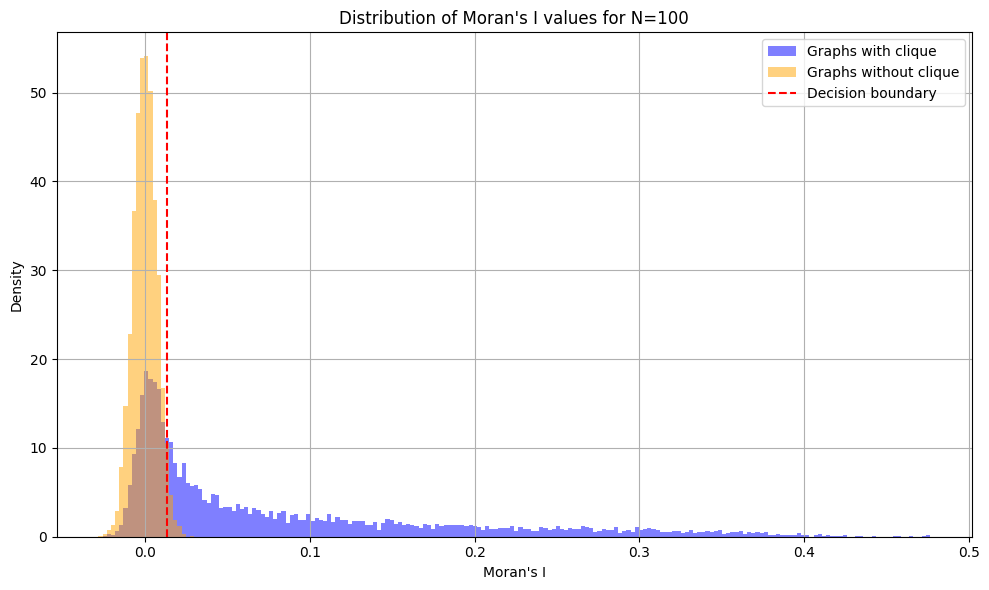

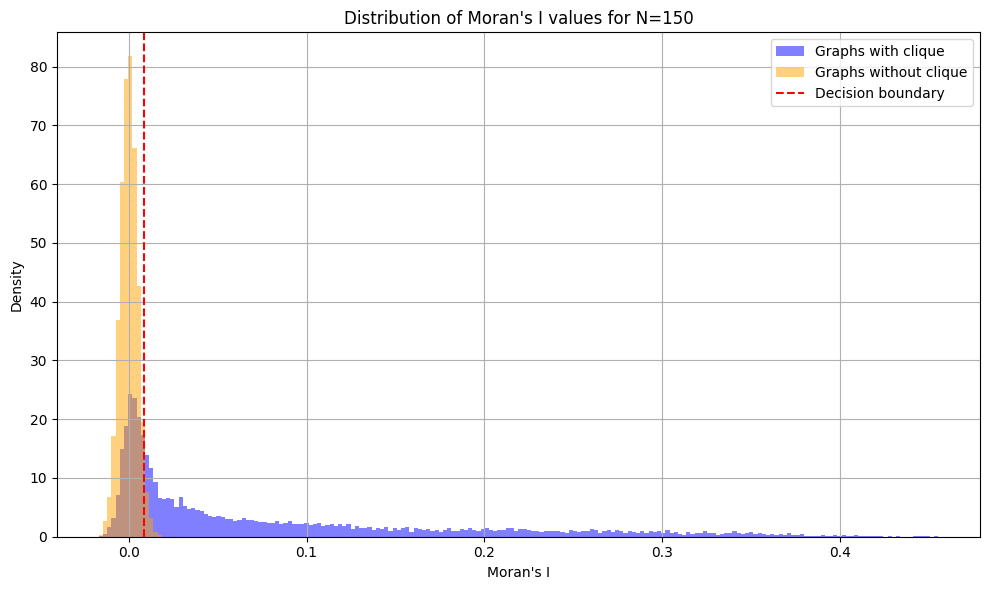

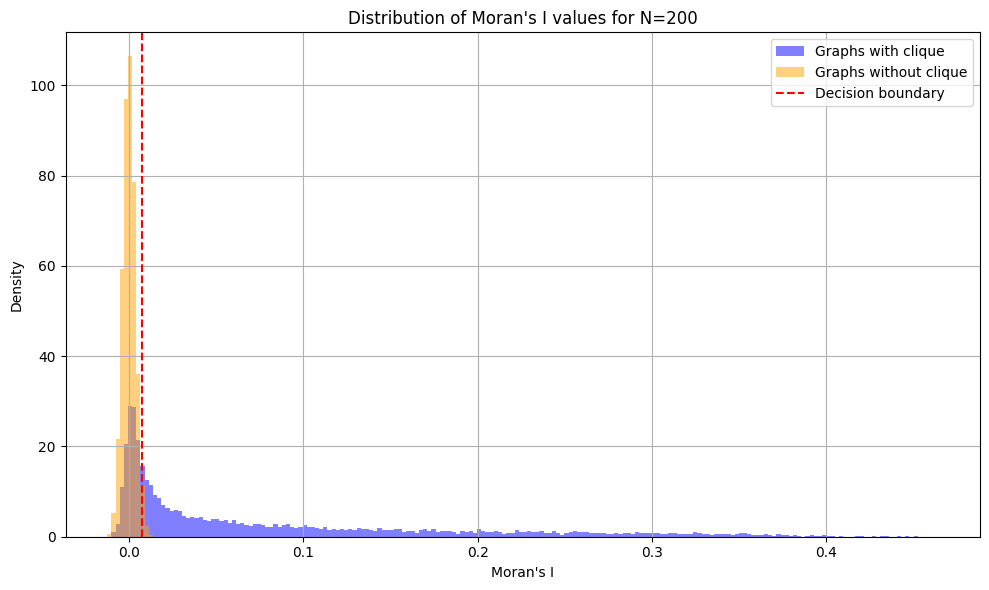

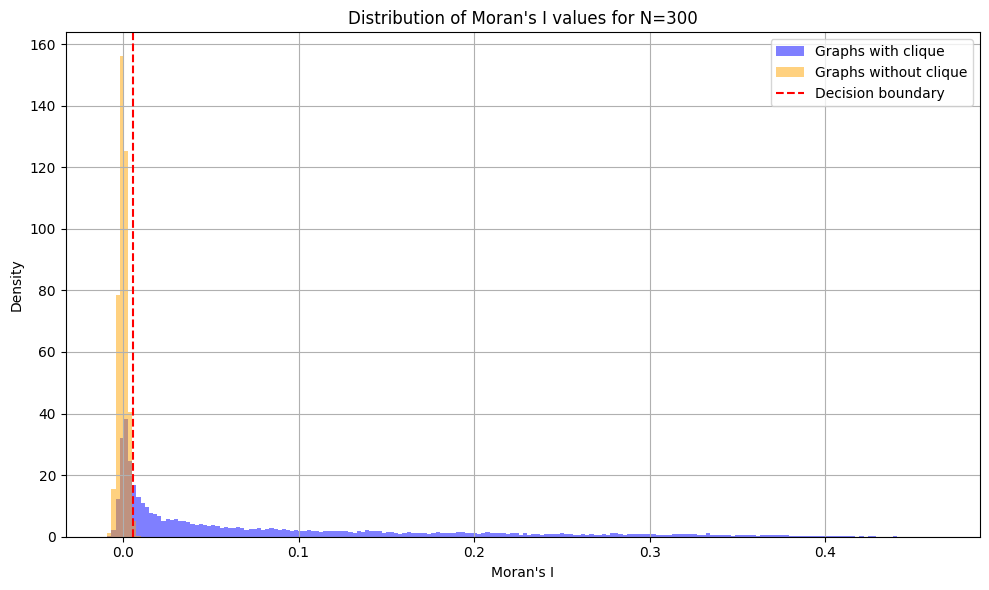

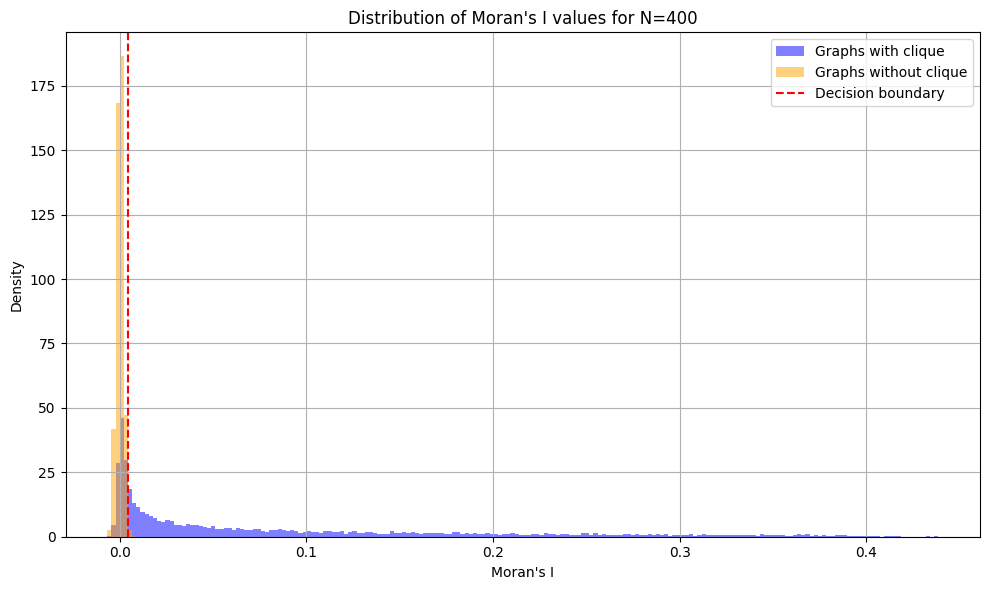

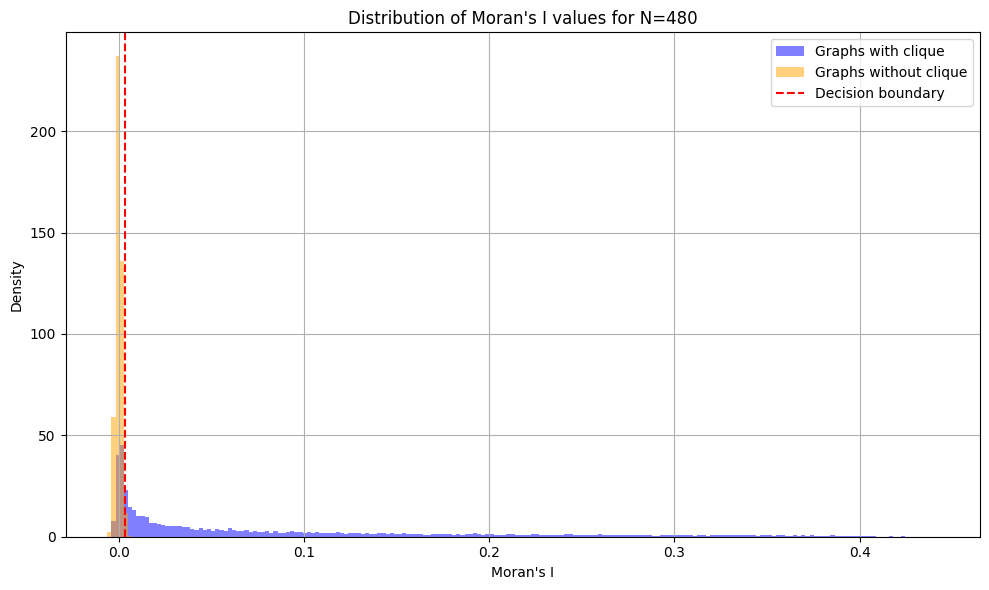

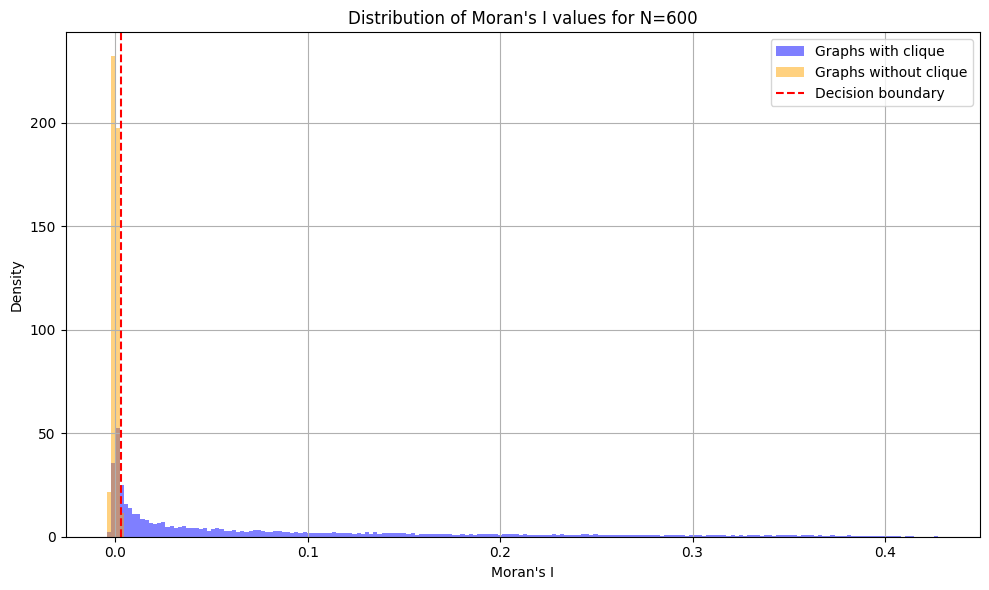

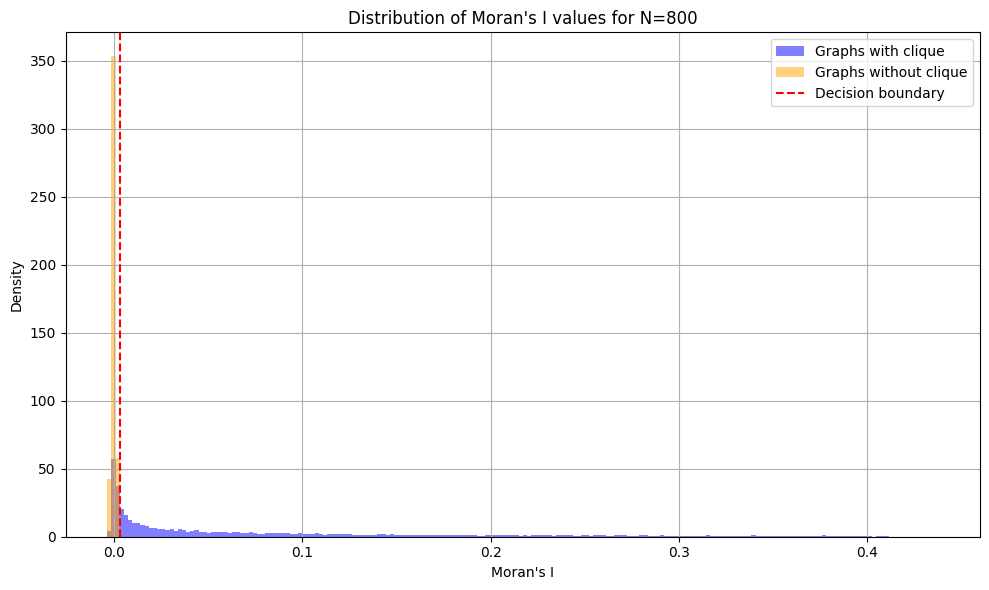

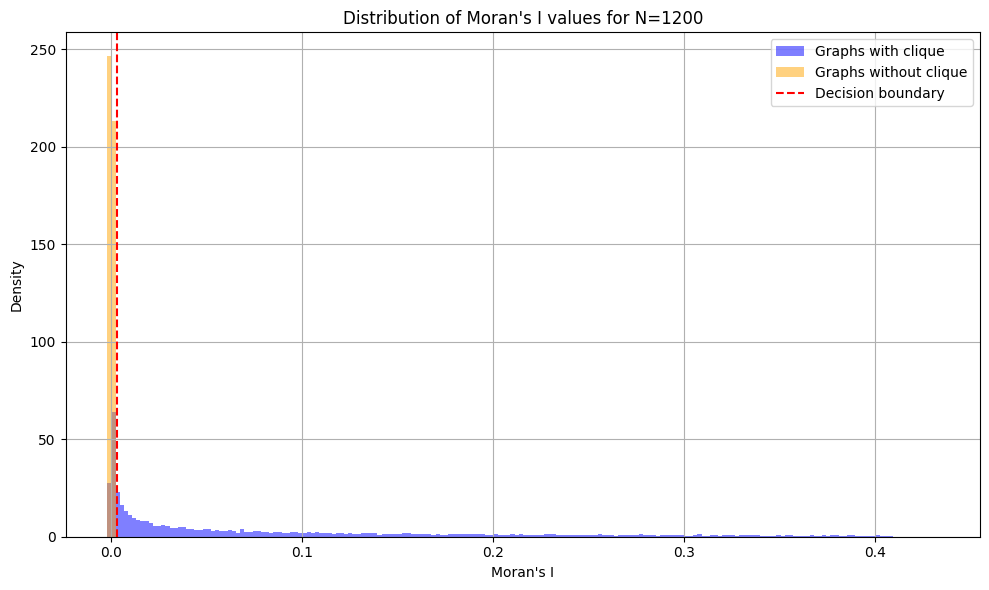

In [ ]:
# read configuration file:
config = load_config(
    os.path.join("Moran-observer_test_config.yml")
)  # CHANGE THIS TO PERFORM DIFFERENT EXPERIMENTS
 
# looping over the different graph sizes in the experiment:
for graph_size in config["graph_size_values"]:
 
    # Create empty dictionaries for storing Moran's I values and decision boundary for current graph size:
    morans_I_clique_results = {}    # Moran's I (at max_radius) for graphs with a clique, keyed by clique size
    morans_I_noclique_results = {}  # Moran's I (at max_radius) for graphs without a clique, keyed by clique size
    decision_boundary = {}  # decision boundary for current graph size (single value, not keyed by clique size)
     
    # Calculate max clique size (proportion of graph size):
    max_clique_size_proportion_test = config["parameters"]["max_clique_size_proportion_test"]
    max_clique_size = int(
        max_clique_size_proportion_test * graph_size
    )
 
    # Calculate array of clique sizes for all test curriculum
    # NOTE: if max clique size is smaller than the number of test levels, use max clique size as the number of test levels
    clique_sizes = np.linspace(
        max_clique_size,
        1,
        num=min(max_clique_size, config["parameters"]["clique_testing_levels"]),
    ).astype(int)
 
    # Divide num_pool in equal batches:
    batch_size = config["parameters"]["num_pool"] // config["parameters"]["num_batches"]
    num_iterations = config["parameters"]["num_batches"]
 
    # Loop for decreasing clique sizes
    for current_clique_size in clique_sizes:
 
        for iter_idx in range(num_iterations):
            clique_size_array = graphs_gen.generate_batch_clique_sizes(np.array([current_clique_size]), batch_size)
 
            # generating graphs with the current clique size and computing Moran's I for each graph:
            graphs_clique, _ = graphs_gen.generate_batch(
                batch_size,
                graph_size,
                clique_size_array,
                config["p_correction_type"],
                input_magnification=False,
                p_clique=1
            )
            adj_matrices_clique = graphs_clique[:, 0].cpu().numpy()
            assert adj_matrices_clique.shape == (batch_size, graph_size, graph_size)
 
            # morans_I_numba returns values for radius 0..max_radius.
            # We only want the value AT max_radius, i.e. the last entry, one scalar per graph:
            morans_I_results_currentclique = np.array([
                morans_I.morans_I_numba(adj, config["parameters"]["max_radius"])[-1]
                for adj in adj_matrices_clique
            ])
            morans_I_clique_results.setdefault(current_clique_size, []).extend(
                morans_I_results_currentclique.tolist()
            )
 
            # generating graphs without a clique and computing Moran's I for each graph:
            graphs_noclique, _ = graphs_gen.generate_batch(
                batch_size,
                graph_size,
                clique_size_array,
                config["p_correction_type"],
                input_magnification=False,
                p_clique=1e-10
            )
            adj_matrices_noclique = graphs_noclique[:, 0].cpu().numpy()
            assert adj_matrices_noclique.shape == (batch_size, graph_size, graph_size)
 
            morans_I_results_noclique = np.array([
                morans_I.morans_I_numba(adj, config["parameters"]["max_radius"])[-1]
                for adj in adj_matrices_noclique
            ])
            morans_I_noclique_results.setdefault(current_clique_size, []).extend(
                morans_I_results_noclique.tolist()
            )
                    
    # after all batches and clique sizes have been processed:
    # - define the decision boundary (clique/no_clique) for the current graph size:
    all_I_clique = np.array([v for sub in morans_I_clique_results.values() for v in sub])
    all_I_noclique = np.array([v for sub in morans_I_noclique_results.values() for v in sub])
    # Use a single shared, fine-grained binning for both distributions to compare p(I|clique) and p(I|noclique)
    combined = np.concatenate([all_I_clique, all_I_noclique])
    bin_edges = np.histogram_bin_edges(combined, bins=200)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    # Compute the density of each distribution using the same bin edges
    clique_density, _ = np.histogram(all_I_clique, bins=bin_edges, density=True)
    noclique_density, _ = np.histogram(all_I_noclique, bins=bin_edges, density=True)
    # Find the crossing point(s) of the two distributions to determine the decision boundary
    diff = clique_density - noclique_density
    sign_changes = np.where(np.diff(np.sign(diff)) != 0)[0]

    if len(sign_changes) == 0:
        raise ValueError(
            f"No crossing found for graph size {graph_size}. Check the distributions of Moran's I values for graphs with and without a clique."
        )

    # Find the first crossing where diff goes from negative to positive
    # (clique density overtakes no-clique density), consistent with
    # "report clique for I > I*". With multiple sign changes (likely due to
    # sampling noise near the true crossing), this picks the leftmost such
    # transition, which is more liberal in classifying "clique" than picking
    # the last one would be.
    neg_to_pos = [
        idx for idx in sign_changes if diff[idx] < 0 and diff[idx + 1] > 0
    ]
    if not neg_to_pos:
        raise ValueError(
            f"No negative-to-positive crossing found for graph size {graph_size}, "
            "only positive-to-negative crossing(s). Check the distributions of Moran's I "
            "values for graphs with and without a clique."
        )
    crossing_idx = neg_to_pos[0]

    # Linear interpolation between the two bin centers for a sub-bin estimate.
    x0, x1 = bin_centers[crossing_idx], bin_centers[crossing_idx + 1]
    y0, y1 = diff[crossing_idx], diff[crossing_idx + 1]
    I_star = x0 - y0 * (x1 - x0) / (y1 - y0)

    decision_boundary["value"] = I_star

    # - saving the dictionaries as .csv files:
    # - clique/no clique distributions
    for results_dict, filename in zip([morans_I_clique_results, morans_I_noclique_results], [f"morans_I_clique_results_lambda{config['parameters']['max_radius']}_N{graph_size}.csv", f"morans_I_noclique_results_lambda{config['parameters']['max_radius']}_N{graph_size}.csv"]):
        file_path = os.path.join(
            os.getcwd(), "results", "morans-i_distributions_dv", "files", filename
        )
        with open(file_path, "w") as file:
            writer = csv.writer(file)
            writer.writerow(["clique size", "Moran's I values"])  # Add column labels
            for key, value in results_dict.items():
                writer.writerow([key, value])
    # - decision boundary
    decision_boundary_file_path = os.path.join(
        os.getcwd(), "results", "morans-i_distributions_dv", "files", f"decision_boundary_lambda{config['parameters']['max_radius']}_N{graph_size}.csv"
    )
    with open(decision_boundary_file_path, "w") as file:
        writer = csv.writer(file)
        writer.writerow(["decision boundary"])
        writer.writerow([decision_boundary.get("value", 0)])
    
    # - visualize (and save as plots) the distributions of Moran's I values for graphs with and without a clique (grouping all clique sizes together):
    plt.figure(figsize=(10, 6))
    # clique
    plt.hist(
        [val for sublist in morans_I_clique_results.values() for val in sublist],
        bins=bin_edges,
        alpha=0.5,
        label="Graphs with clique",
        color="blue",
        density=True,
    )
    # no clique
    plt.hist(
        [val for sublist in morans_I_noclique_results.values() for val in sublist],
        bins=bin_edges,
        alpha=0.5,
        label="Graphs without clique",
        color="orange",
        density=True,
    )
    # overlay the decision boundary as a vertical line:
    plt.axvline(
        x=decision_boundary.get("value", 0), color="red", linestyle="--", label="Decision boundary"
    )
    plt.title(f"Distribution of Moran's I values for N={graph_size}")
    plt.xlabel("Moran's I")
    plt.ylabel("Density")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.savefig(
        os.path.join(
            os.getcwd(), "results", "morans-i_distributions_dv", "plots", f"morans_I_distributions_N{graph_size}.png"
        )
    )
    
    print(f"- Moran's I files and distributions for N={graph_size} saved successfully.")


# Testing

Empirically measure the fraction of correct responses obtained with the decision boundaries defined above.

In [3]:
# read configuration file:
config = load_config(
    os.path.join("Moran-observer_test_config.yml")
)

# looping over the different graph sizes in the experiment:
for graph_size in config["graph_size_values"]:
    
    # read the "decision boundary" file:
    file_path = os.path.join(
        os.getcwd(), "results", "morans-i_distributions_dv", "files", f"decision_boundary_lambda{config['parameters']['max_radius']}_N{graph_size}.csv"
    )
    with open(file_path, "r") as file:
        reader = csv.reader(file)
        next(reader)  # Skip the header row
        decision_boundary_value = float(next(reader)[0])
        print(f"Decision boundary for N={graph_size}: {decision_boundary_value}")    

    # Create empty dictionaries for storing testing results:
    fraction_correct_results = {}  # Fraction correct for each clique size
    metrics_results_list = []

    # Calculate max clique size for testing (proportion of graph size):
    max_clique_size_proportion_test = config["parameters"]["max_clique_size_proportion_test"]
    max_clique_size = int(
        max_clique_size_proportion_test * graph_size
    )

    # Calculate array of clique sizes for all test curriculum
    # NOTE: if max clique size is smaller than the the number of test levels, use max clique size as the number of test levels
    clique_sizes = np.linspace(
        max_clique_size,
        1,
        num=min(max_clique_size, config["parameters"]["clique_testing_levels"]),
    ).astype(int)

    # Loop for decreasing clique sizes
    for current_clique_size in clique_sizes:

        # Metrics initialization (for each clique size)
        TP, FP, TN, FN = 0, 0, 0, 0

        # Initialize fraction correct list, updated at each test iteration
        fraction_correct_list = []

        # Loop for testing iterations:
        for test_iter in range(config["parameters"]["test_iterations"]):

            # Generate clique size value of each graph in the current batch
            clique_size_array_test = graphs_gen.generate_batch_clique_sizes(
                np.array([current_clique_size]),
                config["parameters"]["num_test"],
            )

            # Generate validation graphs
            test = graphs_gen.generate_batch(
                config["parameters"]["num_test"],
                graph_size,
                clique_size_array_test,
                config["p_correction_type"],
                False,
            )

            # If Moran's I > decision_boundary, classify as clique (1), else classify as no clique (0)
            # Convert the complete batch from a PyTorch tensor to CPU NumPy arrays once.
            adj_matrices = test[0].detach().cpu().numpy()

            # generate_batch returns shape [batch_size, 1, N, N]
            if adj_matrices.ndim == 4:
                adj_matrices = adj_matrices[:, 0]

            adj_matrices = np.ascontiguousarray(adj_matrices, dtype=np.float64)

            morans_I_values = np.array([
                morans_I.morans_I_numba(
                    adj,
                    int(config["parameters"]["max_radius"])
                )[-1]
                for adj in adj_matrices
            ])

            hard_output = np.array([
                1 if I > decision_boundary_value else 0
                for I in morans_I_values
            ])

            test_labels = np.array(test[1]) # convert list to numpy array
            # print(hard_output.shape, test_labels.shape)   # DEBUGGING

            # transforming hard_output and test_labels to torch tensors:
            hard_output = torch.tensor(hard_output, dtype=torch.float32)
            test_labels = torch.tensor(test[1], dtype=torch.float32)

            # Compute metrics
            TP += ((hard_output == 1) & (test_labels == 1)).sum().item()
            FP += ((hard_output == 1) & (test_labels == 0)).sum().item()
            TN += ((hard_output == 0) & (test_labels == 0)).sum().item()
            FN += ((hard_output == 0) & (test_labels == 1)).sum().item()

            # updating fraction correct list with the accuracy of the current test iteration:
            fraction_correct_list.append(
                (hard_output == test_labels).sum().item()
                / (1.0 * config["parameters"]["num_test"])
            )

        # Updating dictionary after all test iterations for current clique size have been completed:
        fraction_correct_results[current_clique_size] = round(
            sum(fraction_correct_list) / len(fraction_correct_list), 2
        )

        # Computing metrics:
        precision = TP / (TP + FP + 1e-10)
        recall = TP / (TP + FN + 1e-10)
        F1 = 2 * (precision * recall) / (precision + recall + 1e-10)
        # AUC - ROC cannot be calculated (no soft outputs)
        # num_params has no meaning
        metrics_results = {
            "N_value": graph_size,
            "clique_size": current_clique_size,
            "TP": TP,
            "FP": FP,
            "TN": TN,
            "FN": FN,
            "precision": precision,
            "recall": recall,
            "F1": F1,
        }
        metrics_results_list.append(metrics_results)

        # Printing the size of the clique just tested and the corresponding test accuracy:
        print(
            f"||| Completed testing for clique = {current_clique_size}. "
            f"Average fraction correct = {fraction_correct_results[current_clique_size]}"
        )
        print("|||===========================================================")


    # - notify completion of testing:
    print(f"| Finished testing Moran observer at N = {graph_size}.")

    # Saving accuracy results in .csv file:
    # - defining file name and path:
    file_path = os.path.join(
        os.getcwd(), "results", f"Moran-observer_N{graph_size}_fraction_correct.csv"
    )
    # - saving the dictionary as a .csv file:
    with open(file_path, "w") as file:
        writer = csv.writer(file)
        writer.writerow(["clique size", "fraction correct"])  # Add column labels
        for key, value in fraction_correct_results.items():
            writer.writerow([key, value])
    # Saving metrics results in .csv file:
    metrics_df = pd.DataFrame(metrics_results_list)
    # - defining file name and path:
    file_path = os.path.join(
        os.getcwd(), "results", f"Moran-observer_N{graph_size}_metrics.csv"
    )
    metrics_df.to_csv(file_path, index=False)

    print(f"- Moran observer Results saved successfully for N = {graph_size}.")

Configuration file loaded successfully.
Decision boundary for N=1200: 0.0030343965194268518
||| Completed testing for clique = 840. Average fraction correct = 1.0
|||===========================================================
||| Completed testing for clique = 831. Average fraction correct = 1.0
|||===========================================================
||| Completed testing for clique = 823. Average fraction correct = 1.0
|||===========================================================
||| Completed testing for clique = 814. Average fraction correct = 1.0
|||===========================================================
||| Completed testing for clique = 806. Average fraction correct = 1.0
|||===========================================================
||| Completed testing for clique = 797. Average fraction correct = 1.0
|||===========================================================
||| Completed testing for clique = 789. Average fraction correct = 1.0
|||==============================